In [2]:
# Check Python version and key libraries
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

print("Python version:", sys.version)
print("Setup successful! Libraries loaded")

Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Setup successful! Libraries loaded


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
!pip install pandas numpy scikit-learn matplotlib seaborn --quiet
print("Libraries are ready!")

Libraries are ready!


In [5]:
import pandas as pd
import numpy as np

# Reproducibility
np.random.seed(42)
n = 2000

# Generate features
distance_km = np.random.randint(1, 50, n)
traffic = np.random.choice(['Low', 'Medium', 'High'], n)
weather = np.random.choice(['Clear', 'Rain', 'Storm'], n)
vehicle = np.random.choice(['Bike', 'Van', 'Truck'], n)
hour = np.random.randint(0, 24, n)

# Compute delays
base_time = distance_km * 2
traffic_delay = np.where(traffic == 'High', 20,
                 np.where(traffic == 'Medium', 10, 0))
weather_delay = np.where(weather == 'Storm', 25,
                 np.where(weather == 'Rain', 10, 0))
peak_delay = np.where(((hour >= 7) & (hour <= 9)) | ((hour >= 17) & (hour <= 19)), 15, 0)

# Delivery times
delivery_time = base_time + traffic_delay + weather_delay + peak_delay + np.random.randint(0, 10, n)
expected_time = base_time + 10
delayed = (delivery_time > expected_time).astype(int)

# Create dataframe
df = pd.DataFrame({
    'distance_km': distance_km,
    'traffic': traffic,
    'weather': weather,
    'vehicle': vehicle,
    'hour': hour,
    'delivery_time': delivery_time,
    'expected_time': expected_time,
    'delayed': delayed
})

# Save to CSV
df.to_csv('delivery_data.csv', index=False)

print("Dataset created!")
df.head()

Dataset created!


,distance_km,traffic,weather,vehicle,hour,delivery_time,expected_time,delayed
0,39,Low,Rain,Bike,22,97,88,1
1,29,Low,Clear,Bike,19,79,68,1
2,15,High,Storm,Van,19,95,40,1
3,43,Medium,Rain,Truck,11,115,96,1
4,8,High,Storm,Van,12,65,26,1


In [6]:
# Check first 5 rows
df.head()

# Check info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   distance_km    2000 non-null   int64 
 1   traffic        2000 non-null   object
 2   weather        2000 non-null   object
 3   vehicle        2000 non-null   object
 4   hour           2000 non-null   int64 
 5   delivery_time  2000 non-null   int64 
 6   expected_time  2000 non-null   int64 
 7   delayed        2000 non-null   int64 
dtypes: int64(5), object(3)
memory usage: 125.1+ KB


In [8]:
# Load data
df = pd.read_csv('delivery_data.csv')

# Quick look
print(df.head())
print(df.info())
print(df.describe())

# Feature engineering: Peak hours
df['is_peak'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)

# One-hot encoding for categorical columns
df = pd.get_dummies(df, columns=['traffic', 'weather', 'vehicle'], drop_first=True)

# Features and target
X = df.drop('delayed', axis=1)
y = df['delayed']

X.head()

   distance_km traffic weather vehicle  hour  delivery_time  expected_time  \
0           39     Low    Rain    Bike    22             97             88   
1           29     Low   Clear    Bike    19             79             68   
2           15    High   Storm     Van    19             95             40   
3           43  Medium    Rain   Truck    11            115             96   
4            8    High   Storm     Van    12             65             26   

   delayed  
0        1  
1        1  
2        1  
3        1  
4        1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   distance_km    2000 non-null   int64 
 1   traffic        2000 non-null   object
 2   weather        2000 non-null   object
 3   vehicle        2000 non-null   object
 4   hour           2000 non-null   int64 
 5   delivery_time  2000 non-null   int64 
 6 

,distance_km,hour,delivery_time,expected_time,is_peak,traffic_Low,traffic_Medium,weather_Rain,weather_Storm,vehicle_Truck,vehicle_Van
0,39,22,97,88,0,True,False,True,False,False,False
1,29,19,79,68,1,True,False,False,False,False,False
2,15,19,95,40,1,False,False,False,True,False,True
3,43,11,115,96,0,False,True,True,False,True,False
4,8,12,65,26,0,False,False,False,True,False,True


In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


In [18]:
import joblib

# Save model
joblib.dump(rf, 'rf_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [19]:
import joblib

# Load model
rf = joblib.load('rf_model.pkl')

In [21]:
# Example test input
test_input = pd.DataFrame([{
    'distance_km': 10,
    'hour': 14,
    'is_peak': 0,
    'traffic_Medium': 0,
    'traffic_High': 1,
    'weather_Rain': 0,
    'weather_Storm': 0,
    'vehicle_Van': 0,
    'vehicle_Truck': 1
}])

# Ensure all model columns exist
model_cols = rf.feature_names_in_
for col in model_cols:
    if col not in test_input.columns:
        test_input[col] = 0
test_input = test_input[model_cols]

# Predict
prediction = rf.predict(test_input)[0]
print("Prediction:", "Delayed" if prediction==1 else "On-Time")

Prediction: On-Time


In [23]:
import joblib

# Save the Random Forest model
joblib.dump(rf, 'rf_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [24]:
import joblib

# Load the trained Random Forest model
rf = joblib.load('rf_model.pkl')

In [25]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

st.title("Parcel Delivery Delay Predictor")
st.markdown("Enter delivery details to predict if a parcel will be delayed:")

# Load trained model
rf = joblib.load('rf_model.pkl')

# User inputs
distance = st.slider("Distance (km)", 1, 50)
hour = st.slider("Hour of delivery (0-23)", 0, 23)
traffic = st.selectbox("Traffic", ["Low", "Medium", "High"])
weather = st.selectbox("Weather", ["Clear", "Rain", "Storm"])
vehicle = st.selectbox("Vehicle", ["Bike", "Van", "Truck"])

# Feature engineering
is_peak = 1 if (7 <= hour <= 9) or (17 <= hour <= 19) else 0

# One-hot encoding
traffic_medium = 1 if traffic=="Medium" else 0
traffic_high = 1 if traffic=="High" else 0
weather_rain = 1 if weather=="Rain" else 0
weather_storm = 1 if weather=="Storm" else 0
vehicle_van = 1 if vehicle=="Van" else 0
vehicle_truck = 1 if vehicle=="Truck" else 0

# Prepare input DataFrame
input_df = pd.DataFrame([{
    'distance_km': distance,
    'hour': hour,
    'is_peak': is_peak,
    'traffic_Medium': traffic_medium,
    'traffic_High': traffic_high,
    'weather_Rain': weather_rain,
    'weather_Storm': weather_storm,
    'vehicle_Van': vehicle_van,
    'vehicle_Truck': vehicle_truck
}])

# Ensure all model columns exist
for col in rf.feature_names_in_:
    if col not in input_df.columns:
        input_df[col] = 0
input_df = input_df[rf.feature_names_in_]

# Prediction
prediction = rf.predict(input_df)[0]

if st.button("Predict Delay"):
    if prediction == 1:
        st.error("⚠️ This delivery is likely DELAYED!")
    else:
        st.success("✅ This delivery is likely ON-TIME.")

Overwriting app.py


In [ ]:
!nohup streamlit run app.py &
!npx localtunnel --port 8501

nohup: appending output to 'nohup.out'
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙your url is: https://long-doodles-occur.loca.lt


In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Predictions
y_pred_rf = rf.predict(X_test)

# Metrics
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.9775

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.83      0.87        36
           1       0.98      0.99      0.99       364

    accuracy                           0.98       400
   macro avg       0.95      0.91      0.93       400
weighted avg       0.98      0.98      0.98       400


Confusion Matrix:
 [[ 30   6]
 [  3 361]]


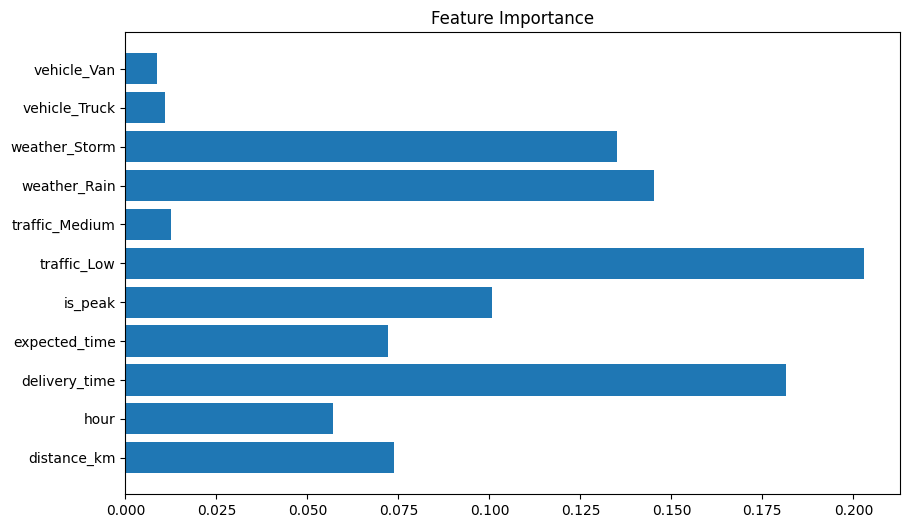

In [11]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
features = X.columns

plt.figure(figsize=(10,6))
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

In [13]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 74.5 MB/s eta 0:00:00


In [14]:
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from pyngrok import ngrok

In [15]:
# Load dataset
df = pd.read_csv('delivery_data.csv')

# Feature engineering
df['is_peak'] = df['hour'].apply(lambda x: 1 if (7 <= x <= 9) or (17 <= x <= 19) else 0)
df = pd.get_dummies(df, columns=['traffic', 'weather', 'vehicle'], drop_first=True)

X = df.drop('delayed', axis=1)
y = df['delayed']

# Train Random Forest
rf = RandomForestClassifier()
rf.fit(X, y)

RandomForestClassifier()

In [16]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
import pickle

# Load model (we trained in Colab session)
# Here we will just use the model from main session

st.title("Parcel Delivery Delay Predictor")

st.markdown("Enter the delivery details to predict if the parcel will be delayed:")

# Inputs
distance = st.slider("Distance (km)", 1, 50)
hour = st.slider("Hour of delivery (0-23)", 0, 23)
traffic = st.selectbox("Traffic", ["Low", "Medium", "High"])
weather = st.selectbox("Weather", ["Clear", "Rain", "Storm"])
vehicle = st.selectbox("Vehicle", ["Bike", "Van", "Truck"])

# Feature engineering
is_peak = 1 if (7 <= hour <= 9) or (17 <= hour <= 19) else 0

# One-hot encode categorical features
traffic_low = 1 if traffic=="Medium" or traffic=="High" else 0
traffic_medium = 1 if traffic=="Medium" else 0
weather_rain = 1 if weather=="Rain" else 0
weather_storm = 1 if weather=="Storm" else 0
vehicle_van = 1 if vehicle=="Van" else 0
vehicle_truck = 1 if vehicle=="Truck" else 0

# Prepare input for model
input_df = pd.DataFrame([{
    'distance_km': distance,
    'hour': hour,
    'is_peak': is_peak,
    'traffic_Medium': traffic_medium,
    'traffic_High': 1 if traffic=="High" else 0,
    'weather_Rain': weather_rain,
    'weather_Storm': weather_storm,
    'vehicle_Van': vehicle_van,
    'vehicle_Truck': vehicle_truck
}])

# Fill missing columns (if any)
model_cols = rf.feature_names_in_
for col in model_cols:
    if col not in input_df.columns:
        input_df[col] = 0
input_df = input_df[model_cols]

# Predict
prediction = rf.predict(input_df)[0]

if st.button("Predict Delay"):
    if prediction == 1:
        st.error("⚠️ This delivery is likely DELAYED!")
    else:
        st.success("✅ This delivery is likely ON-TIME.")

Writing app.py


In [17]:
!nohup streamlit run app.py &
!npx localtunnel --port 8501

nohup: appending output to 'nohup.out'
⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://wide-parks-knock.loca.lt
^C
